In [1]:
# ===========================================================================
#                                Sütun adları
# ===========================================================================
# PJM_Load: Bütün PJM sistemi üzrə ümumi saatlıq elektrik enerjisi istehlakı.
# PJME: PJM sisteminin şərq zonası (East) üzrə enerji tələbatı.
# PJMW: PJM sisteminin qərb zonası (West) üzrə enerji tələbatı.
# NI: Şimali İllinoys (Northern Illinois) bölgəsinin enerji yükü.
# AEP: Ohayo mərkəzli American Electric Power şirkətinin xidmət zonası.
# DAYTON: Ohayo ştatının Deyton şəhəri və ətrafının enerji paylayıcısı.
# DUQ: Pensilvaniya ştatının Pittsburq bölgəsini əhatə edən Duquesne Light şirkəti.
# DOM: Virciniya və Şimali Karolinaya xidmət edən Dominion Virginia Power şirkəti.
# COMED: Çikaqo və ətraf bölgələrin əsas enerji təminatçısı Commonwealth Edison.
# FE: Ohayo və Nyu-Cersi daxil olmaqla bir neçə ştatda fəaliyyət göstərən FirstEnergy.
# DEOK: Ohayo və Kentukkidə fəaliyyət göstərən Duke Energy Ohio & Kentucky zonası.
# EKPC: Şərqi Kentukki Elektrik Kooperativi (East Kentucky Power Cooperative) tərəfindən idarə olunan zona.

In [2]:
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder

In [3]:
import kagglehub

path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")
print(path)

C:\Users\emilm\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3


In [4]:
import os

files = os.listdir(path)
print(files)

['AEP_hourly.csv', 'COMED_hourly.csv', 'DAYTON_hourly.csv', 'DEOK_hourly.csv', 'DOM_hourly.csv', 'DUQ_hourly.csv', 'EKPC_hourly.csv', 'est_hourly.paruqet', 'FE_hourly.csv', 'NI_hourly.csv', 'PJME_hourly.csv', 'PJMW_hourly.csv', 'pjm_hourly_est.csv', 'PJM_Load_hourly.csv']


In [5]:
import pandas as pd
import os

for file in os.listdir(path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(path, file))
        print(file, df.shape)
        print(df.columns)
        print("-" * 50)

AEP_hourly.csv (121273, 2)
Index(['Datetime', 'AEP_MW'], dtype='object')
--------------------------------------------------
COMED_hourly.csv (66497, 2)
Index(['Datetime', 'COMED_MW'], dtype='object')
--------------------------------------------------
DAYTON_hourly.csv (121275, 2)
Index(['Datetime', 'DAYTON_MW'], dtype='object')
--------------------------------------------------
DEOK_hourly.csv (57739, 2)
Index(['Datetime', 'DEOK_MW'], dtype='object')
--------------------------------------------------
DOM_hourly.csv (116189, 2)
Index(['Datetime', 'DOM_MW'], dtype='object')
--------------------------------------------------
DUQ_hourly.csv (119068, 2)
Index(['Datetime', 'DUQ_MW'], dtype='object')
--------------------------------------------------
EKPC_hourly.csv (45334, 2)
Index(['Datetime', 'EKPC_MW'], dtype='object')
--------------------------------------------------
FE_hourly.csv (62874, 2)
Index(['Datetime', 'FE_MW'], dtype='object')
--------------------------------------------------


In [6]:
import pandas as pd
import os

all_dfs = []

for file in os.listdir(path):
    if file.endswith(".csv") and file != "pjm_hourly_est.csv":
        df = pd.read_csv(os.path.join(path, file))
        region = df.columns[1].replace("_MW", "")
        df.columns = ['Datetime', 'Load']
        df['region'] = region
        all_dfs.append(df)

data = pd.concat(all_dfs, ignore_index=True)
data['Datetime'] = pd.to_datetime(data['Datetime'])
data = data.set_index('Datetime').sort_index()

print(data.head())
print(data['region'].unique())
print(data.shape)

                        Load    region
Datetime                              
1998-04-01 01:00:00  22259.0  PJM_Load
1998-04-01 02:00:00  21244.0  PJM_Load
1998-04-01 03:00:00  20651.0  PJM_Load
1998-04-01 04:00:00  20421.0  PJM_Load
1998-04-01 05:00:00  20713.0  PJM_Load
['PJM_Load' 'PJME' 'PJMW' 'NI' 'AEP' 'DAYTON' 'DUQ' 'DOM' 'COMED' 'FE'
 'DEOK' 'EKPC']
(1090167, 2)


In [7]:
data.reset_index(inplace=True)

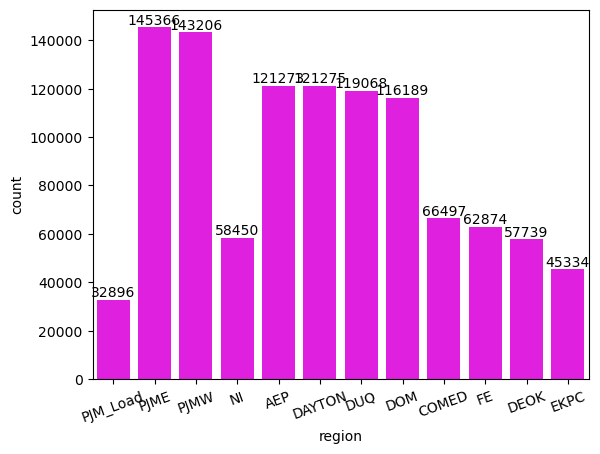

In [8]:
ax = sns.countplot(data=data, x='region',color='magenta')
ax.bar_label(ax.containers[0])

plt.xticks(rotation=20);

In [9]:
data.groupby('region')['Load'].mean().sort_values(ascending=False)

region
PJME        32080.222831
PJM_Load    29766.427408
AEP         15499.513717
NI          11701.682943
COMED       11420.152112
DOM         10949.203625
FE           7792.159064
PJMW         5602.375089
DEOK         3105.096486
DAYTON       2037.851140
DUQ          1658.820296
EKPC         1464.218423
Name: Load, dtype: float64

In [10]:
le = LabelEncoder()
le.fit(data['region'])
data['region'] = le.transform(data['region'])

In [11]:
data

,Datetime,Load,region
0,1998-04-01 01:00:00,22259.0,11
1,1998-04-01 02:00:00,21244.0,11
2,1998-04-01 03:00:00,20651.0,11
3,1998-04-01 04:00:00,20421.0,11
4,1998-04-01 05:00:00,20713.0,11
...,...,...,...
1090162,2018-08-03 00:00:00,13335.0,1
1090163,2018-08-03 00:00:00,35486.0,9
1090164,2018-08-03 00:00:00,1656.0,5
1090165,2018-08-03 00:00:00,11385.0,4


In [12]:
df = data

In [79]:
# hour: Günün saatını göstərir və elektrik istehlakının gün ərzindəki (məsələn, səhər və axşam) pik vaxtlarını müəyyən edir.
# dayofweek: Həftənin gününü rəqəmlə ifadə edir və iş günləri ilə istirahət günləri arasındakı fərqi üzə çıxarır.
# month: İlin ayını bildirir və mövsümi dəyişiklikləri (məsələn, yayda kondisioner, qışda isitmə istifadəsi) modelə tanıdır.
# is_weekend: Günün şənbə-bazar olub-olmadığını göstərən binar (0 və ya 1) dəyərdir və həftəsonu dəyişən yükü qeyd edir.
# lag_24: Dəqiq 24 saat əvvəlki yük miqdarıdır və modelə "dünən bu vaxt nə qədər enerji işlənmişdi?" sualının cavabını verir.
# lag_168: Bir həftə (168 saat) əvvəlki yük miqdarıdır və keçən həftənin eyni günü ilə müqayisə aparmağa imkan yaradır.
# rolling_mean_24: Son 24 saatın orta yük dəyəridir və datadakı qəfil sıçrayışları hamarlayaraq ümumi trendi göstərir.
# region: Məlumatın hansı paylayıcı zonaya aid olduğunu bildirir və modelin hər regionun özünəməxsus profilini tanımasını təmin edir.

In [13]:
def add_features(df):
    df = df.copy()
    df['hour']       = df['Datetime'].dt.hour
    df['dayofweek']  = df['Datetime'].dt.dayofweek
    df['month']      = df['Datetime'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    
    # lag features
    df['lag_24']  = df.groupby('region')['Load'].shift(24)   # 1 gun evveli
    df['lag_168'] = df.groupby('region')['Load'].shift(168)  # 1 həftə evvel
    df['rolling_mean_24'] = df.groupby('region')['Load'].transform(
        lambda x: x.shift(1).rolling(24, min_periods=1).mean())
    
    df = df.dropna().reset_index(drop=True)
    return df

df = add_features(df)

In [81]:
df.head()

,Datetime,Load,region,hour,dayofweek,month,is_weekend,lag_24,lag_168,rolling_mean_24
0,1998-04-08 02:00:00,20826.0,11,2,2,4,0,21483.0,22259.0,26750.833333
1,1998-04-08 03:00:00,20279.0,11,3,2,4,0,21211.0,21244.0,26723.458333
2,1998-04-08 04:00:00,20118.0,11,4,2,4,0,21250.0,20651.0,26684.625000
3,1998-04-08 05:00:00,20503.0,11,5,2,4,0,21819.0,20421.0,26637.458333
4,1998-04-08 06:00:00,22243.0,11,6,2,4,0,23751.0,20713.0,26582.625000


In [44]:
# Train / Test Split
split = int(len(df)*0.2)
train = df.iloc[split:].copy()
test = df.iloc[:split].copy()

In [89]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

features = ['hour', 'dayofweek', 'month', 'is_weekend',
            'lag_24', 'lag_168', 'rolling_mean_24', 'region']

xgb = XGBRegressor(n_estimators=500, learning_rate=0.03,
                   max_depth=10, random_state=42, n_jobs=-1)

xgb.fit(train_df[FEATURES], train_df['Load'])


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [90]:
test_df['pred'] = xgb.predict(test_df[features])

In [91]:

print(f"MAE : {mean_absolute_error(test_df['Load'], test_df['pred']):.2f}")
print(f"MAPE: {mape(test_df['Load'], test_df['pred']):.2f}%")

MAE : 537.45
MAPE: 3.38%


In [95]:
from sklearn.metrics import r2_score
print(f"R2  : {r2_score(test_df['Load'], test_df['pred']):.4f}")

R2  : 0.9946


## EDA

In [69]:
import matplotlib.dates as mdates

regions = test_df['region'].unique()
region_labels = {
    0: 'PJM_Load', 1: 'PJME', 2: 'PJMW', 3: 'NI', 4: 'AEP',
    5: 'DAYTON', 6: 'DUQ', 7: 'DOM', 8: 'COMED', 9: 'FE',
    10: 'DEOK', 11: 'EKPC'
}

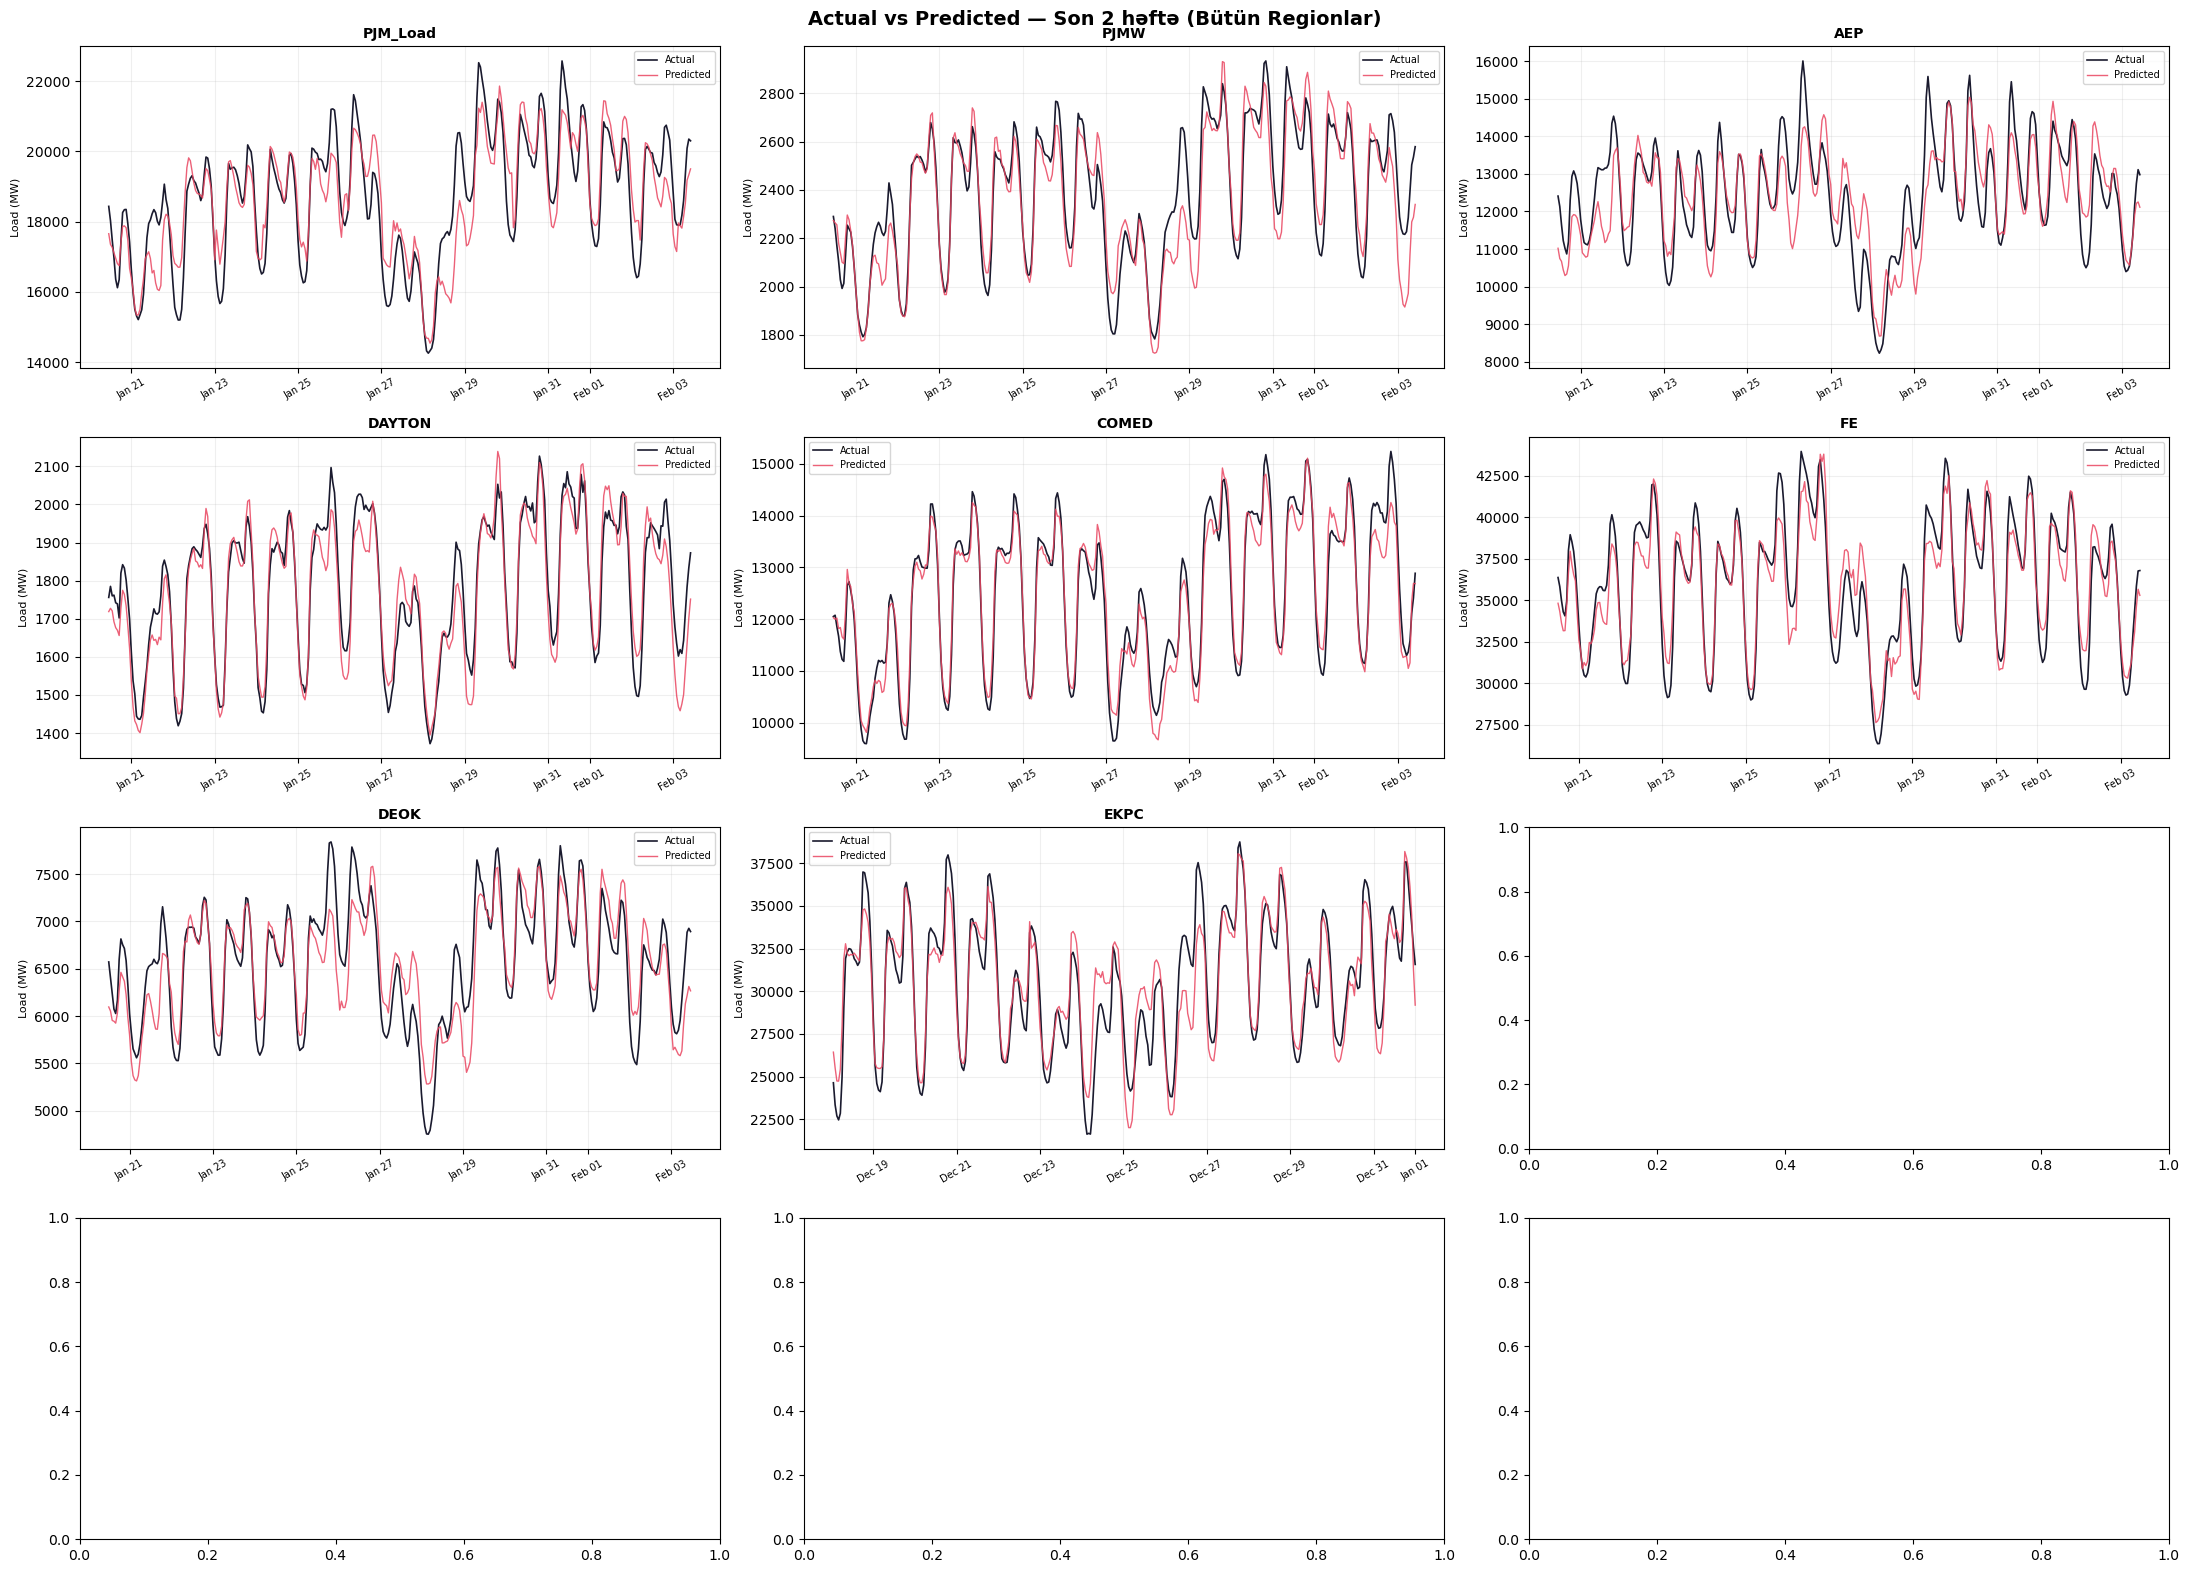

In [71]:
#  Hər region üçün Actual vs Predicted 
# Hər regionda proqnozun real dataya nə qədər uyğun olduğu
fig, axes = plt.subplots(4, 3, figsize=(22, 16))
axes = axes.flatten()

for i, region in enumerate(sorted(regions)):
    te = test_df[test_df['region'] == region].tail(24 * 14)
    ax = axes[i]
    ax.plot(te['Datetime'], te['Load'],  label='Actual',    color='#1a1a2e', lw=1.2)
    ax.plot(te['Datetime'], te['pred'],  label='Predicted', color='#e94560', lw=1, alpha=0.85)
    ax.set_title(region_labels.get(region, region), fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_ylabel('Load (MW)', fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('Actual vs Predicted — Son 2 həftə (Bütün Regionlar)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()


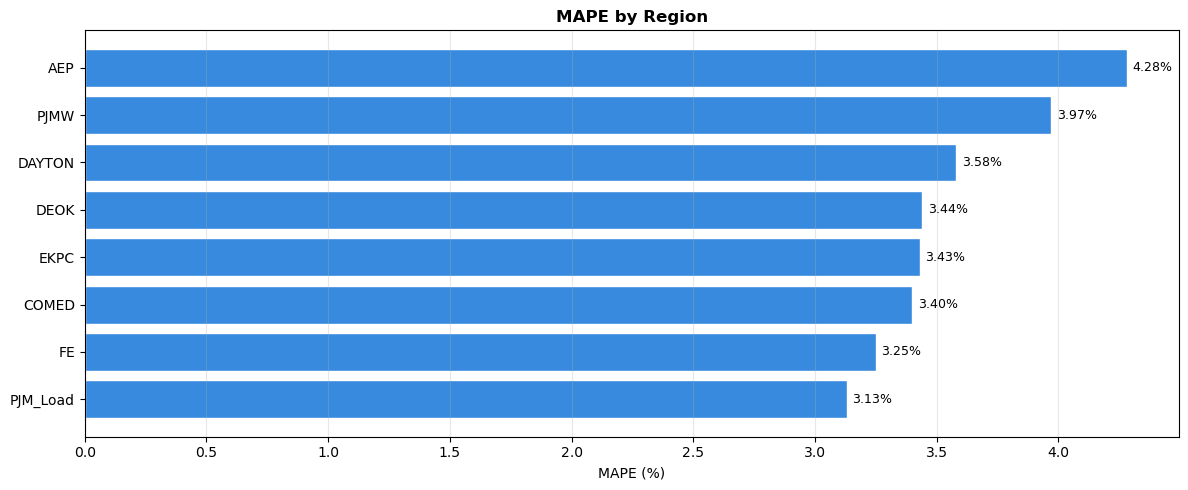

In [73]:
# MAPE hər region üçün bar chart
# Hansı region MAPE  daha dəqiq proqnoz edilib
summary = []
for region in sorted(regions):
    te = test_df[test_df['region'] == region]
    m  = mape(te['Load'], te['pred'])
    summary.append({'Region': region_labels.get(region, region), 'MAPE': round(m, 2)})

res = pd.DataFrame(summary).sort_values('MAPE')

fig2, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(res['Region'], res['MAPE'], color='#378ADD', edgecolor='white')
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=9)
ax.set_xlabel('MAPE (%)')
ax.set_title('MAPE by Region', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('mape_by_region.png', dpi=150, bbox_inches='tight')
plt.show()


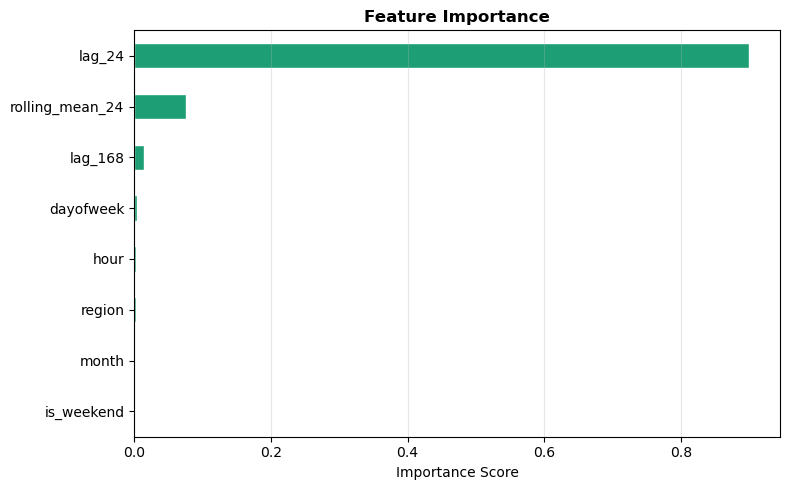

In [75]:
# Feature Importance 
# Hansı sütun modelin qərarına daha çox təsir edir
FEATURES = ['hour', 'dayofweek', 'month', 'is_weekend',
            'lag_24', 'lag_168', 'rolling_mean_24', 'region']

feat_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values()

fig3, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='#1D9E75', edgecolor='white')
ax.set_title('Feature Importance', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

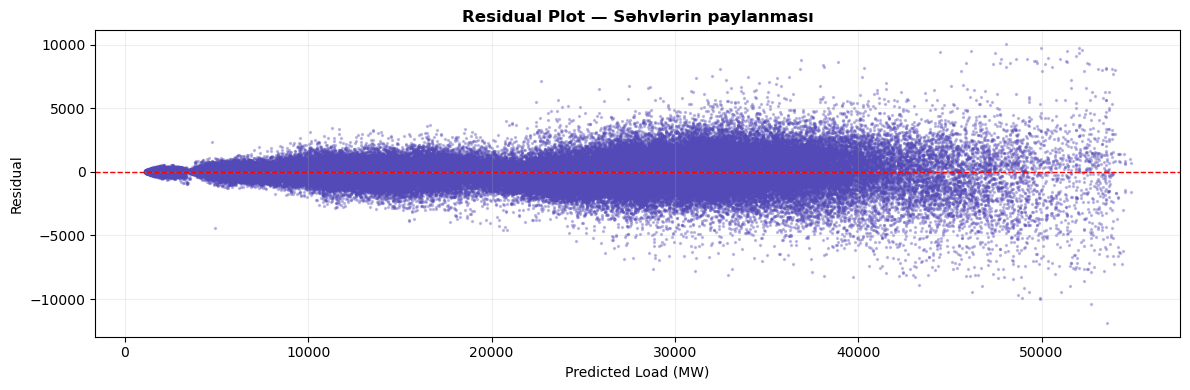

In [77]:
#  Residual Plot 
# Modelin sistematik xətası varmı
test_df['residual'] = test_df['Load'] - test_df['pred']

fig4, ax = plt.subplots(figsize=(12, 4))
ax.scatter(test_df['pred'], test_df['residual'],
           alpha=0.3, s=2, color='#534AB7')
ax.axhline(0, color='red', lw=1, ls='--')
ax.set_xlabel('Predicted Load (MW)')
ax.set_ylabel('Residual')
ax.set_title('Residual Plot — Səhvlərin paylanması', fontweight='bold')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()